# Notebook 0: Setup & Preflight Checks

## Machine Learning and Computational Imaging for Astrophysics
**CTA200H — May 14, 2026 | Rohan Dahale**

---

**Run this notebook BEFORE the lecture begins.** It will:
1. Verify your Python environment
2. Check that all required packages are available
3. Install `ehtim` (the EHT imaging library)
4. Confirm that data files are in place
5. Run a quick JAX smoke test

**Estimated time: 5 minutes.**

---

### Connecting to CITA with VS Code

#### 1. SSH Config (on your laptop)

Add the following to `~/.ssh/config` on your **local machine** (create the file if it doesn't exist):

```
Host cita-gw
    HostName gw.cita.utoronto.ca
    User YOUR_USERNAME

Host cosmo1
    HostName cosmo1
    User YOUR_USERNAME
    ProxyJump cita-gw

Host cosmo2
    HostName cosmo2
    User YOUR_USERNAME
    ProxyJump cita-gw

Host cosmo3
    HostName cosmo3
    User YOUR_USERNAME
    ProxyJump cita-gw

Host cosmo4
    HostName cosmo4
    User YOUR_USERNAME
    ProxyJump cita-gw
```

Replace `YOUR_USERNAME` with your CITA username. Use your assigned cosmo node (based on birthday).

#### 2. Connect with VS Code

1. Install the **Remote - SSH** and **Jupyter** extensions in VS Code
2. Press `Cmd+Shift+P` (Mac) or `Ctrl+Shift+P` (Windows/Linux)
3. Type **"Remote-SSH: Connect to Host"** → select your cosmo node (e.g., `cosmo1`)
4. Enter your password and GAuth verification code when prompted
5. Once connected, open the folder `~/CTA200H/lectures/machine_learning/`

#### 3. Select the Python Kernel

**Option A — Start Jupyter from terminal (recommended):**

1. In VS Code, open a terminal (`Terminal` → `New Terminal`)
2. Run:
   ```bash
   module load python/3.12.11
   jupyter notebook --no-browser --port=8888
   ```
3. Copy the URL with token (e.g., `http://localhost:8888/?token=abc123...`)
4. In the notebook, click the kernel selector (top-right) → **"Select Another Kernel..."** → **"Existing Jupyter Server..."** → paste the URL

**Option B — Direct interpreter selection:**

1. Click the kernel selector (top-right) → **"Select Another Kernel..."** → **"Python Environments..."**
2. Look for `Python 3.12.11` in the list and select it
3. If it's not listed, type `/cita/modules/python/3.12.11/bin/python3` in the search/filter box at the top

> **Why this specific Python?** The system has multiple Python versions. Only `python/3.12.11` has JAX, ehtim, and all the packages we need. The older `python/3.10.16` has a broken `_ctypes` module.

## Step 1: Python Version Check

In [1]:
import sys

print(f"Python version: {sys.version}")
print(f"Python path: {sys.executable}")

if sys.version_info < (3, 12):
    print("\n" + "="*60)
    print("ERROR: You need Python 3.12+")
    print("Run this in your terminal first:")
    print("  module load python/3.12.11")
    print("Then restart VS Code / reselect the Python interpreter.")
    print("="*60)
else:
    print("\n✓ Python version is OK!")

Python version: 3.12.11 (main, Jul  7 2025, 12:59:32) [GCC 8.5.0 20210514 (Red Hat 8.5.0-26)]
Python path: /cita/modules/python/3.12.11/bin/python3.12

✓ Python version is OK!


## Step 2: Core Packages Check

These packages are pre-installed in the system Python. If any fail, something is wrong with the module load.

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import jax
import jax.numpy as jnp

print(f"NumPy:      {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"SciPy:      {scipy.__version__}")
print(f"JAX:        {jax.__version__}")
print()
print("✓ All core packages loaded successfully!")

NumPy:      1.26.4
Matplotlib: 3.10.3
SciPy:      1.16.0
JAX:        0.6.2

✓ All core packages loaded successfully!


## Step 3: Install eht-imaging

[eht-imaging](https://github.com/achael/eht-imaging) is the Python library used by the Event Horizon Telescope collaboration to simulate observations and reconstruct images of black holes.

In [3]:
import subprocess

try:
    import ehtim as eh
    print(f"ehtim is already installed!")
except ImportError:
    print("Installing ehtim...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--user", "--quiet", "ehtim"]
    )
    import ehtim as eh
    print(f"\n✓ ehtim installed successfully!")

print("\nNote: For production work, you may also want pynfft for faster transforms:")
print("  conda install -c conda-forge pynfft")
print("This is NOT required for today's lecture.")

/home/rdahale/.local/lib/python3.12/site-packages/ehtim/__init__.py:58: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Welcome to eht-imaging! v 1.2.10 

ehtim is already installed!

Note: For production work, you may also want pynfft for faster transforms:
  conda install -c conda-forge pynfft
This is NOT required for today's lecture.


## Step 4: Verify Data Files

The lecture uses pre-bundled data files: telescope array configurations and black hole model images from the eht-imaging repository.

In [4]:
import os

# Data directory (relative to this notebook)
data_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data")
if not os.path.exists(data_dir):
    data_dir = os.path.expanduser("~/CTA200H/lectures/machine_learning/data")

required_files = [
    "arrays/EHT2017.txt",
    "models/avery_sgra_eofn.txt",
]

all_ok = True
for f in required_files:
    path = os.path.join(data_dir, f)
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"  ✓ {f} ({size_kb:.0f} KB)")
    else:
        print(f"  ✗ MISSING: {path}")
        all_ok = False

if all_ok:
    print(f"\n✓ All data files present in {data_dir}")
else:
    print("\nSome data files are missing!")
    print("Try: cd ~/CTA200H && git pull")

  ✓ arrays/EHT2017.txt (1 KB)
  ✓ models/avery_sgra_eofn.txt (652 KB)

✓ All data files present in /home/rdahale/CTA200H/lectures/machine_learning/data


## Step 5: JAX Smoke Test

Let's verify that JAX's automatic differentiation works correctly.

In [5]:
# Test 1: Basic gradient
f = lambda x: x**3
df = jax.grad(f)
result = df(2.0)
expected = 12.0
print(f"jax.grad(x³) at x=2.0 = {result}  (expected: {expected})")
assert jnp.isclose(result, expected), "JAX grad test failed!"

# Test 2: JIT compilation
f_jit = jax.jit(f)
result_jit = f_jit(3.0)
print(f"jax.jit(x³) at x=3.0 = {result_jit}  (expected: 27.0)")
assert jnp.isclose(result_jit, 27.0), "JAX jit test failed!"

# Test 3: Array operations
a = jnp.array([1.0, 2.0, 3.0])
print(f"jnp.sum([1,2,3]²) = {jnp.sum(a**2)}  (expected: 14.0)")

print("\n✓ JAX is fully functional!")

jax.grad(x³) at x=2.0 = 12.0  (expected: 12.0)
jax.jit(x³) at x=3.0 = 27.0  (expected: 27.0)
jnp.sum([1,2,3]²) = 14.0  (expected: 14.0)

✓ JAX is fully functional!


## Step 6: Quick Matplotlib Test

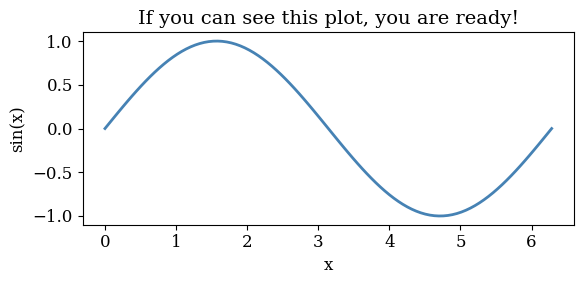

✓ Plotting works!


In [6]:
%matplotlib inline

x = np.linspace(0, 2*np.pi, 100)
plt.figure(figsize=(6, 3))
plt.plot(x, np.sin(x), color='steelblue', linewidth=2)
plt.title('If you can see this plot, you are ready!', fontsize=14)
plt.xlabel('x'); plt.ylabel('sin(x)')
plt.tight_layout()
plt.show()

print("✓ Plotting works!")

---

## All checks passed!

You're ready for the lecture. Here's what we'll cover:

| Notebook | Topic | Time |
|----------|-------|------|
| **01** | Machine Learning: loss functions, gradient descent, JAX | 30 min |
| **02** | Computational Imaging: Fourier transforms, building an imager | 35 min |
| **03** | Neural Networks & real-world imaging with ehtim | 35 min |
| **04** | Frontiers & connections to your research | 10 min |

---

### Optional: AI Coding Tools

These tools can help you explore code and debug during the tutorial session:

- **GitHub Copilot**: Free for students via [GitHub Education](https://education.github.com/pack). Works in VS Code.
- **Claude Code**: `npm install -g @anthropic-ai/claude-code` (requires Node.js and an API key)
- **OpenAI Codex**: Available as a VS Code extension or CLI

None of these are required for the lecture.

---

### Troubleshooting

**Problem: `ModuleNotFoundError` for JAX or other packages**
- Make sure you selected the correct kernel: `/cita/modules/python/3.12.11/bin/python3`
- Click the kernel name in the top-right of the notebook → "Select Another Kernel" → "Enter interpreter path" → paste the path above
- Do NOT use `python/3.10.16` — it has a known `_ctypes` bug

**Problem: VS Code can't connect to cosmo node**
- Make sure your `~/.ssh/config` has the `ProxyJump cita-gw` line
- You may need to enter your password twice (once for gateway, once for cosmo)
- If using CITA VPN, you can connect directly without ProxyJump

**Problem: `pip install ehtim` fails**
- Try: `pip install --user ehtim` (note the `--user` flag)
- If behind a proxy: `pip install --user --proxy $http_proxy ehtim`

**Problem: Data files missing**
- Run `cd ~/CTA200H && git pull` to get the latest files
- Or ask the instructor for a copy

**Problem: Plots don't show**
- Make sure the Jupyter extension is installed in VS Code (on the remote side too)
- Try restarting the kernel: click the restart button in the toolbar

**Problem: Kernel keeps dying**
- You may be on a busy node. Try a different cosmo node.
- Check memory: open a terminal in VS Code and run `free -h`